# Data Cleaning

*Data Loading & First Look*

In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# load the data 
laptop = pd.read_csv("laptopData.csv")


In [3]:
# show the first 5 rows 
laptop.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [4]:
# show the information about the dataset
laptop.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   str    
 2   TypeName          1273 non-null   str    
 3   Inches            1273 non-null   str    
 4   ScreenResolution  1273 non-null   str    
 5   Cpu               1273 non-null   str    
 6   Ram               1273 non-null   str    
 7   Memory            1273 non-null   str    
 8   Gpu               1273 non-null   str    
 9   OpSys             1273 non-null   str    
 10  Weight            1273 non-null   str    
 11  Price             1273 non-null   float64
dtypes: float64(2), str(10)
memory usage: 122.3 KB


اكتشفت وجود 30 صف فيها قيم ناقصة

In [5]:
# show the statistical description
laptop.describe()

,Unnamed: 0,Price
count,1273.000000,1273.000000
mean,652.674784,59955.814073
std,376.493027,37332.251005
min,0.000000,9270.720000
25%,327.000000,31914.720000
50%,652.000000,52161.120000
75%,980.000000,79333.387200
max,1302.000000,324954.720000


In [6]:
print("Number of Rows, Number of Columns",laptop.shape)

Number of Rows, Number of Columns (1303, 12)


In [7]:
laptop.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='str')

In [8]:
# Check missing values
laptop.isnull().sum()
print(laptop.isnull().sum())

Unnamed: 0          30
Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64


اكتشفت وجود 30 صف فارغ

In [9]:
# Check if any duplicated rows
print(laptop.duplicated().sum()) 

29


اكتشفت وجود 29 صف متكرر

In [10]:
laptop.nunique()

Unnamed: 0          1273
Company               19
TypeName               6
Inches                25
ScreenResolution      40
Cpu                  118
Ram                   10
Memory                40
Gpu                  110
OpSys                  9
Weight               189
Price                777
dtype: int64

In [11]:
# create a copy after demoving missing values
laptop_clean = laptop.dropna().copy()
laptop_clean.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [12]:
# compare between the data before and after removing missing values
print("Before removing missing values: ", laptop.shape)
print("After removing missing values: ", laptop_clean.shape)

Before removing missing values:  (1303, 12)
After removing missing values:  (1273, 12)


In [13]:
print("Number of duplicate rows: ", laptop_clean.duplicated().sum())

Number of duplicate rows:  0


قبل تنظيف كان هناك 29 صف متكرر ولكن بعد إزالة التكرار مع القيم الفارغة أصبح الان بدون تكرار و قيم فارغة.

In [14]:
laptop_clean.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [15]:
# remove unnamed column

laptop_clean = laptop_clean.drop(columns=["Unnamed: 0"])


In [16]:
laptop_clean.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='str')

تم حذف أول عامود لعدم الحاجة إليه كونه مجرد رقم متزايد 

# Feature Engineering

In [17]:
# create new column 'Ram' from string type to integer type 

laptop_clean["Ram_GB"] = laptop_clean["Ram"].str.replace("GB","").astype(int)
laptop_clean[["Ram", "Ram_GB"]].head()

,Ram,Ram_GB
0,8GB,8
1,8GB,8
2,8GB,8
3,16GB,16
4,8GB,8


In [18]:
# create new column 'weight' from string type to float type 

print(laptop_clean["Weight"].unique())

laptop_clean[laptop_clean["Weight"] == "?"]

<StringArray>
[ '1.37kg',  '1.34kg',  '1.86kg',  '1.83kg',   '2.1kg',  '2.04kg',   '1.3kg',
   '1.6kg',   '2.2kg',  '0.92kg',
 ...
   '3.0kg',  '0.99kg',  '0.69kg',  '3.52kg', '2.591kg',  '2.21kg',   '3.3kg',
 '2.191kg',  '2.34kg',   '4.0kg']
Length: 189, dtype: str


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Ram_GB
208,Dell,Ultrabook,13.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,?,77202.72,8


In [19]:
# create a temporary to clean some format of weight

weight_clean = laptop_clean["Weight"].str.replace("kg", "").str.strip()

weight_clean = weight_clean.replace(["?" , ""], np.nan)

print("The missing values for weight clean: ", weight_clean.isnull().sum())

laptop_clean["Weight"][weight_clean.isnull()]


The missing values for weight clean:  1


208    ?
Name: Weight, dtype: str

In [20]:
# create new column 'weight' from text type to number type 

laptop_clean["Weight_kg"] = weight_clean.astype(float)

laptop_clean = laptop_clean.dropna(subset=["Weight_kg"]).copy()

laptop_clean[["Weight", "Weight_kg"]].head()



,Weight,Weight_kg
0,1.37kg,1.37
1,1.34kg,1.34
2,1.86kg,1.86
3,1.83kg,1.83
4,1.37kg,1.37


في عامود الوزن قبل ماأحول من نص إلى رقم ظهر معي خطأ بوجود علامة '؟' و 'مسافات في بداية الخانة' ولكن أول شي حولتها إلى NaN ومن ثم خزنتها في متغير حتى أستفيد من العامودين في المقارنات و الرسومات  

In [21]:

print(laptop_clean["Inches"].unique())

laptop_clean[laptop_clean["Inches"] == "?"]

<StringArray>
['13.3', '15.6', '15.4',   '14',   '12', '17.3', '13.5', '12.5',   '13',
 '18.4', '13.9', '11.6', '25.6', '35.6', '12.3', '27.3',   '24', '33.5',
    '?', '31.6',   '17',   '15', '14.1', '11.3', '10.1']
Length: 25, dtype: str


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Ram_GB,Weight_kg
476,Dell,Workstation,?,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg,128298.24,8,1.78


In [22]:
# create a temporary to clean some format of inches

inches_clean = laptop_clean["Inches"].str.strip()

inches_clean = inches_clean.replace(["?" , ""], np.nan)

print("The missing values for inches clean: ", inches_clean.isnull().sum())

laptop_clean["Inches"][inches_clean.isnull()]


The missing values for inches clean:  1


476    ?
Name: Inches, dtype: str

In [23]:
# create new column 'Inches_float' from text type to number type 

laptop_clean["Inches_float"] = inches_clean.astype(float)

laptop_clean = laptop_clean.dropna(subset=["Inches_float"]).copy()

laptop_clean[["Inches", "Inches_float"]].head()

,Inches,Inches_float
0,13.3,13.3
1,13.3,13.3
2,15.6,15.6
3,15.4,15.4
4,13.3,13.3


In [24]:
laptop_clean["Gpu"].unique()

<StringArray>
['Intel Iris Plus Graphics 640',       'Intel HD Graphics 6000',
        'Intel HD Graphics 620',           'AMD Radeon Pro 455',
 'Intel Iris Plus Graphics 650',                'AMD Radeon R5',
      'Intel Iris Pro Graphics',         'Nvidia GeForce MX150',
       'Intel UHD Graphics 620',        'Intel HD Graphics 520',
 ...
      'Nvidia GeForce GTX 980 ',           'AMD Radeon R5 M330',
           'AMD FirePro W4190M',           'AMD FirePro W6150M',
           'AMD Radeon R5 M315',          'Nvidia Quadro M500M',
           'AMD Radeon R7 M360',         'Nvidia Quadro M3000M',
          'Nvidia GeForce 960M',            'ARM Mali T860 MP4']
Length: 110, dtype: str

In [25]:
# create 'GPU brand' from 'GPU' column
laptop_clean["GPU_Brand"] = laptop_clean["Gpu"].str.split().str[0]

laptop_clean[["Gpu", "GPU_Brand"]]
laptop_clean["GPU_Brand"].value_counts()


GPU_Brand
Intel     702
Nvidia    392
AMD       176
ARM         1
Name: count, dtype: int64

In [26]:
laptop_clean.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Ram_GB,Weight_kg,Inches_float,GPU_Brand
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,8,1.37,13.3,Intel
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,8,1.34,13.3,Intel
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,8,1.86,15.6,Intel
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,16,1.83,15.4,AMD
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,8,1.37,13.3,Intel


In [27]:
laptop_clean["Cpu"].unique()

<StringArray>
[                'Intel Core i5 2.3GHz',
                 'Intel Core i5 1.8GHz',
           'Intel Core i5 7200U 2.5GHz',
                 'Intel Core i7 2.7GHz',
                 'Intel Core i5 3.1GHz',
              'AMD A9-Series 9420 3GHz',
                 'Intel Core i7 2.2GHz',
           'Intel Core i7 8550U 1.8GHz',
           'Intel Core i5 8250U 1.6GHz',
             'Intel Core i3 6006U 2GHz',
 ...
          'Intel Atom x5-Z8550 1.44GHz',
 'Intel Pentium Dual Core 4405Y 1.5GHz',
 'Intel Pentium Quad Core N3700 1.6GHz',
             'Intel Core M 6Y54 1.1GHz',
          'Intel Core i7 6500U 2.50GHz',
   'Intel Celeron Dual Core N3350 2GHz',
        'Samsung Cortex A72&A53 2.0GHz',
             'AMD E-Series 9000 2.2GHz',
             'Intel Core M 6Y30 0.9GHz',
            'AMD A9-Series 9410 2.9GHz']
Length: 118, dtype: str

In [28]:
# create 'CPU brand' from 'CPU' column

laptop_clean["CPU_Brand"] = laptop_clean["Cpu"].str.split().str[0]

laptop_clean[["Cpu", "CPU_Brand"]]
laptop_clean["CPU_Brand"].value_counts()


CPU_Brand
Intel      1208
AMD          62
Samsung       1
Name: count, dtype: int64

In [29]:
print(laptop_clean["Memory"].unique())

<StringArray>
[                    '128GB SSD',           '128GB Flash Storage',
                     '256GB SSD',                     '512GB SSD',
                     '500GB HDD',           '256GB Flash Storage',
                       '1TB HDD',          '128GB SSD +  1TB HDD',
        '256GB SSD +  256GB SSD',            '64GB Flash Storage',
            '32GB Flash Storage',          '256GB SSD +  1TB HDD',
          '256GB SSD +  2TB HDD',                      '32GB SSD',
                       '2TB HDD',                      '64GB SSD',
                  '1.0TB Hybrid',          '512GB SSD +  1TB HDD',
                       '1TB SSD',        '256GB SSD +  500GB HDD',
          '128GB SSD +  2TB HDD',        '512GB SSD +  512GB SSD',
                      '16GB SSD',            '16GB Flash Storage',
        '512GB SSD +  256GB SSD',          '512GB SSD +  2TB HDD',
 '64GB Flash Storage +  1TB HDD',                     '180GB SSD',
            '1TB HDD +  1TB HDD',               

In [30]:
print(laptop_clean["Memory"].value_counts())

Memory
256GB SSD                        399
1TB HDD                          217
500GB HDD                        130
512GB SSD                        116
128GB SSD +  1TB HDD              92
128GB SSD                         74
256GB SSD +  1TB HDD              71
32GB Flash Storage                37
2TB HDD                           16
64GB Flash Storage                14
512GB SSD +  1TB HDD              14
1TB SSD                           13
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
128GB Flash Storage                4
180GB SSD                          4
16GB SSD                           3
512GB SSD +  2TB HDD               3
256GB SSD +  256GB SSD             2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
1TB SSD +  1TB HDD                 2
512GB Flash Storage                2
64GB SSD                       

In [31]:
laptop_clean["Memory"].value_counts()

Memory
256GB SSD                        399
1TB HDD                          217
500GB HDD                        130
512GB SSD                        116
128GB SSD +  1TB HDD              92
128GB SSD                         74
256GB SSD +  1TB HDD              71
32GB Flash Storage                37
2TB HDD                           16
64GB Flash Storage                14
512GB SSD +  1TB HDD              14
1TB SSD                           13
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
128GB Flash Storage                4
180GB SSD                          4
16GB SSD                           3
512GB SSD +  2TB HDD               3
256GB SSD +  256GB SSD             2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
1TB SSD +  1TB HDD                 2
512GB Flash Storage                2
64GB SSD                       

In [32]:
# create a temporary to clean some format of memory

memory_clean = laptop_clean["Memory"].str.strip()

memory_clean = memory_clean.replace(["?" , ""], np.nan)

print("The missing values for memory clean: ", memory_clean.isnull().sum())

laptop_clean["Memory"] = memory_clean

laptop_clean = laptop_clean.dropna(subset=["Memory"]).copy()

The missing values for memory clean:  1


In [33]:
# create storage for each types
laptop_clean["Has_SSD"] = laptop_clean["Memory"].str.contains("SSD").astype(int) 
laptop_clean["Has_HDD"] = laptop_clean["Memory"].str.contains("HDD").astype(int)
laptop_clean["Has_Flash_Storage"] = laptop_clean["Memory"].str.contains("Flash Storage").astype(int)
laptop_clean["Has_Hybrid"] = laptop_clean["Memory"].str.contains("Hybrid").astype(int)

In [34]:
laptop_clean[["Memory", "Has_SSD", "Has_HDD", "Has_Flash_Storage", "Has_Hybrid"]].head(10)

,Memory,Has_SSD,Has_HDD,Has_Flash_Storage,Has_Hybrid
0,128GB SSD,1,0,0,0
1,128GB Flash Storage,0,0,1,0
2,256GB SSD,1,0,0,0
3,512GB SSD,1,0,0,0
4,256GB SSD,1,0,0,0
5,500GB HDD,0,1,0,0
6,256GB Flash Storage,0,0,1,0
7,256GB Flash Storage,0,0,1,0
8,512GB SSD,1,0,0,0
9,256GB SSD,1,0,0,0


In [35]:
laptop_clean["OpSys"].value_counts()

OpSys
Windows 10      1044
No OS             63
Linux             61
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            1
Name: count, dtype: int64

In [36]:
# create a new column for operating systems names

laptop_clean["OS_Name"] = laptop_clean["OpSys"].replace({
    "Windows 10": "Windows",
    "Windows 7": "Windows",
    "Windows 10 S": "Windows",
    "macOS": "Mac",
    "Mac OS X": "Mac",
    "Linux": "Linux",
    "Chrome OS": "Chrome OS",
    "Android": "Android",
    "No OS": "Other"
})
#    هنا أنشات مجموعة فيها جميع أسماء أنظمة التشغيل وصنفتها على حسب نظام الجهاز لتبسيطها بشكل أكثر كفاءة.

In [37]:
# check OS_Name counts after simply into a group
laptop_clean["OS_Name"].value_counts()

OS_Name
Windows      1097
Other          63
Linux          61
Chrome OS      27
Mac            21
Android         1
Name: count, dtype: int64

In [38]:
laptop_clean["ScreenResolution"].value_counts()

ScreenResolution
Full HD 1920x1080                                492
1366x768                                         274
IPS Panel Full HD 1920x1080                      226
IPS Panel Full HD / Touchscreen 1920x1080         52
Full HD / Touchscreen 1920x1080                   45
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  14
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160                9
IPS Panel 1366x768                                 7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
Touchscreen 2560x1440                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [39]:
# create a new column for screen resolution 
laptop_clean["Touch_Screen"] = laptop_clean["ScreenResolution"].str.contains("Touchscreen").astype(int)

# create a new column for IPS feature 
laptop_clean["IPS"] = laptop_clean["ScreenResolution"].str.contains("IPS").astype(int)

# create two colums for resolution width and resolution height
resolution = laptop_clean["ScreenResolution"].str.extract(r'(\d+)x(\d+)')

laptop_clean["Resolution_Width"] = resolution[0].astype(int)
laptop_clean["Resolution_Height"] = resolution[1].astype(int)

 
# هنا أنشأت عامودين من عامود دقة الشاشة استخرجت منها هل الشاشة تعمل باللمس أم لا والعامود الاخر هل الشاشة فيها خاصية IPS ام لا

In [40]:
laptop_clean[[
    "ScreenResolution", 
    "Touch_Screen", 
    "IPS", 
    "Resolution_Width", 
    "Resolution_Height"]
].head()

,ScreenResolution,Touch_Screen,IPS,Resolution_Width,Resolution_Height
0,IPS Panel Retina Display 2560x1600,0,1,2560,1600
1,1440x900,0,0,1440,900
2,Full HD 1920x1080,0,0,1920,1080
3,IPS Panel Retina Display 2880x1800,0,1,2880,1800
4,IPS Panel Retina Display 2560x1600,0,1,2560,1600


In [41]:
laptop_clean.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price', 'Ram_GB', 'Weight_kg',
       'Inches_float', 'GPU_Brand', 'CPU_Brand', 'Has_SSD', 'Has_HDD',
       'Has_Flash_Storage', 'Has_Hybrid', 'OS_Name', 'Touch_Screen', 'IPS',
       'Resolution_Width', 'Resolution_Height'],
      dtype='str')

In [42]:
laptop_clean.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,CPU_Brand,Has_SSD,Has_HDD,Has_Flash_Storage,Has_Hybrid,OS_Name,Touch_Screen,IPS,Resolution_Width,Resolution_Height
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,...,Intel,1,0,0,0,Mac,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,...,Intel,0,0,1,0,Mac,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,...,Intel,1,0,0,0,Other,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,...,Intel,1,0,0,0,Mac,0,1,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,...,Intel,1,0,0,0,Mac,0,1,2560,1600


In [43]:
# check the shape after adding new columns
rows, columns = laptop_clean.shape
print("The number of rows:", rows)
print("The number of columns:", columns)

# check missing value after feature engineering
print(laptop_clean.isnull().sum())

The number of rows: 1270
The number of columns: 25
Company              0
TypeName             0
Inches               0
ScreenResolution     0
Cpu                  0
Ram                  0
Memory               0
Gpu                  0
OpSys                0
Weight               0
Price                0
Ram_GB               0
Weight_kg            0
Inches_float         0
GPU_Brand            0
CPU_Brand            0
Has_SSD              0
Has_HDD              0
Has_Flash_Storage    0
Has_Hybrid           0
OS_Name              0
Touch_Screen         0
IPS                  0
Resolution_Width     0
Resolution_Height    0
dtype: int64


 في نهاية جزئية feature engineering طبعت إحصائية لمعرفة عدد الصفوف والأعمدة والتأكد من أخرى إذا كان هناك أي قيم فارغة

# Visualization

سأستكشف البيانات باستخدام ثلاثة أنواع من التحليل: التحليل الأحادي المتغير، والتحليل الثنائي المتغير، والتحليل متعدد المتغيرات  من خلال الرسومات البيانية لفهم البيانات بشكل أفضل قبل بناء النموذج

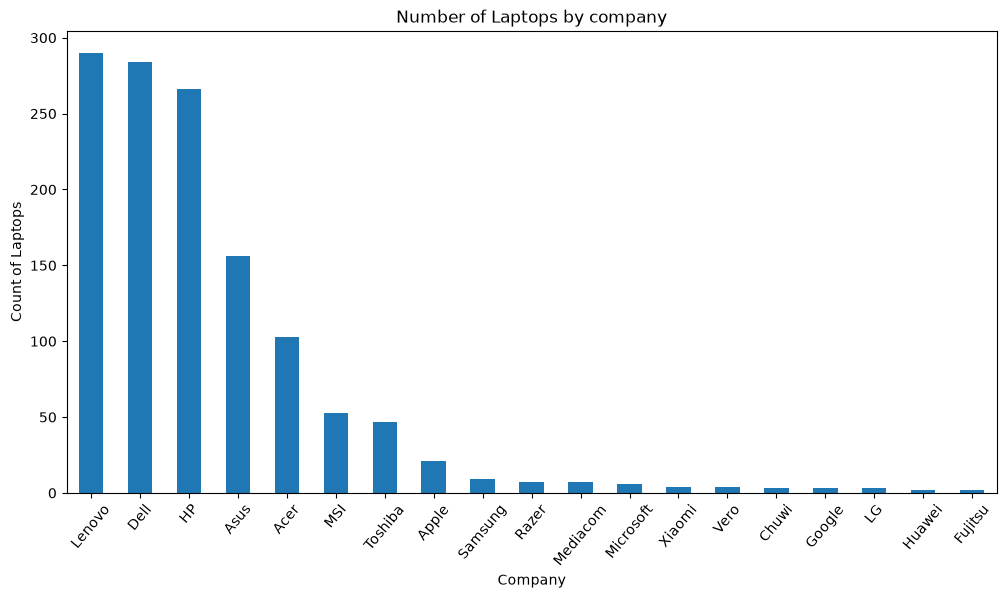

In [44]:
# laptop companies 'Univariate analysis'

plt.figure(figsize=(12,6))
laptop_clean["Company"].value_counts().plot(kind="bar")
plt.title("Number of Laptops by company")
plt.xlabel("Company")
plt.ylabel("Count of Laptops")
plt.xticks(rotation=50)
plt.show()


# في هذي الرسمة استعرضنا جميع الشركات وعدد اللابتوبات 

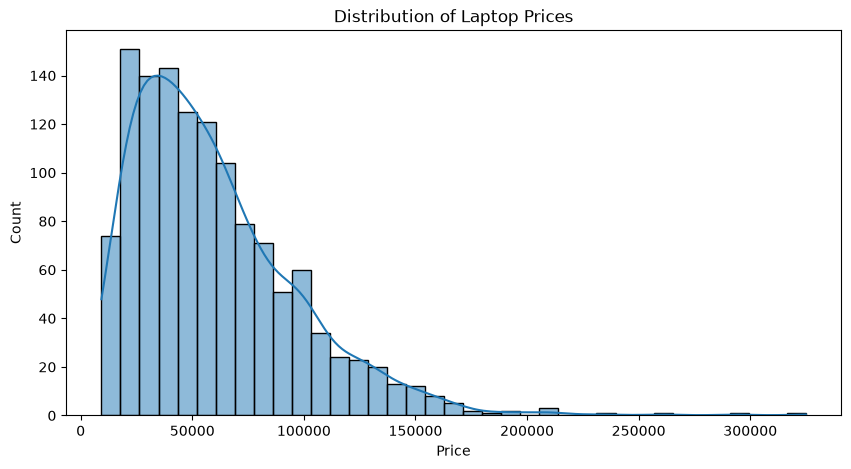

In [45]:
# distribution of laptop prices 'Univariate analysis'

plt.figure(figsize=(10,5))
sns.histplot(laptop_clean["Price"], kde=True)
plt.title("Distribution of Laptop Prices") 
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# هذي الرسمة توضح لنا أسعار اللابتوبات وعددها

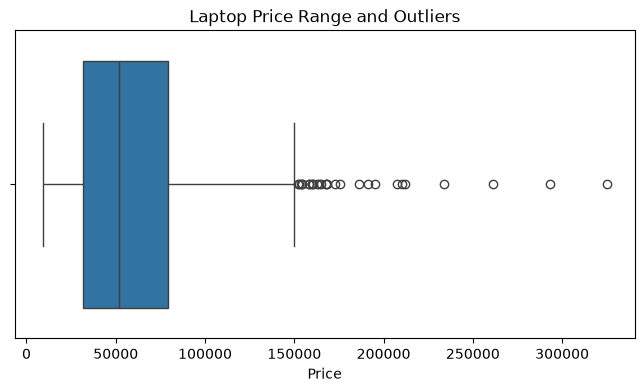

In [46]:
# boxplot of laptop prices 'Univariate analysis'

plt.figure(figsize=(8,4))
sns.boxplot(x = laptop_clean["Price"])
plt.title("Laptop Price Range and Outliers")
plt.xlabel("Price")
plt.show()

# في هذي الرسمة توضح لنا نطاق الأسعار والقيم العالية outliers

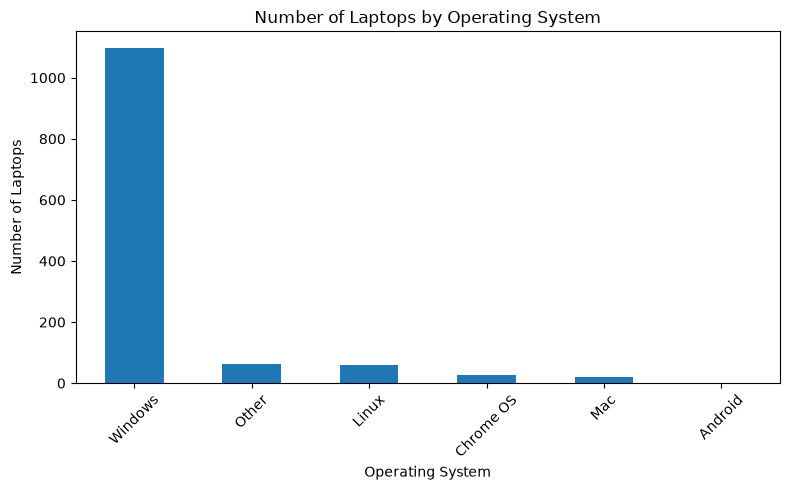

In [47]:
# number of laptops by operating system 'Univariate analysis'

plt.figure(figsize=(8, 5))
laptop_clean["OS_Name"].value_counts().plot(kind="bar")
plt.title("Number of Laptops by Operating System")
plt.xlabel("Operating System")
plt.ylabel("Number of Laptops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# في هذي الرسمة توصح لنا عدد اللابتوبات لكل نظام تشغيل 

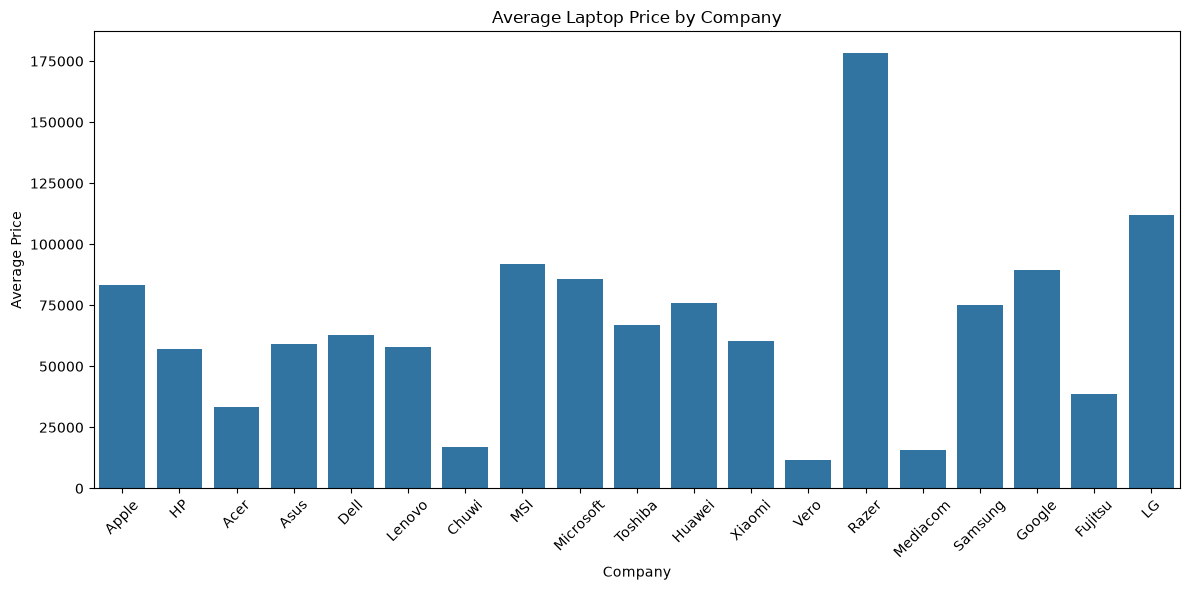

In [48]:
# average laptop price by company 'Bivariate analysis'

plt.figure(figsize=(12, 6))

sns.barplot(data=laptop_clean, x="Company", y="Price", estimator="mean", errorbar=None)

plt.title("Average Laptop Price by Company")
plt.xlabel("Company")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# الرسمة توضح لنا العلاقة بين متوسط سعر اللابتوب بالنسبة لشركة وتم عرض جميع الشركات مع متوسط الأسعار 

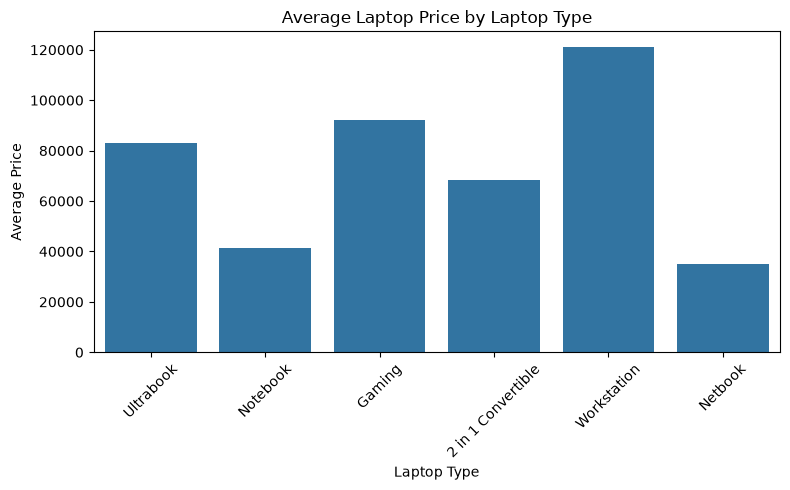

In [49]:
# average price by laptop type 'Bivariate analysis'

plt.figure(figsize=(8, 5))
sns.barplot(data=laptop_clean, x="TypeName", y="Price", errorbar=None)
plt.title("Average Laptop Price by Laptop Type")
plt.xlabel("Laptop Type")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# الرسمة توضح لنا علاقة متوسط السعر بالنسبة لنوع اللابتوب 

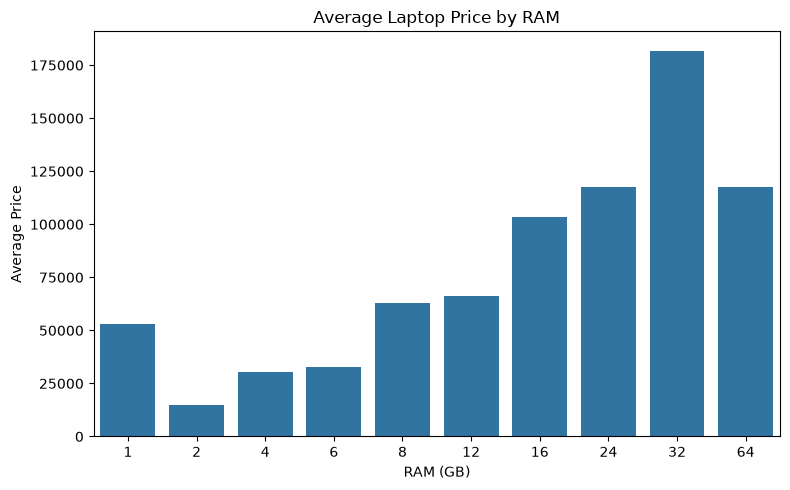

In [50]:
# average price by RAM 'Bivariate analysis'

plt.figure(figsize=(8, 5))
sns.barplot(data=laptop_clean, x="Ram_GB", y="Price", errorbar=None)
plt.title("Average Laptop Price by RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Average Price")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# الرسمة توضح لنا العلاقة بين متوسط السعر بالنسبة لنوع او رقم الرام ويتضح لنا كل رام لديه متوسط خاص به عن الاخر

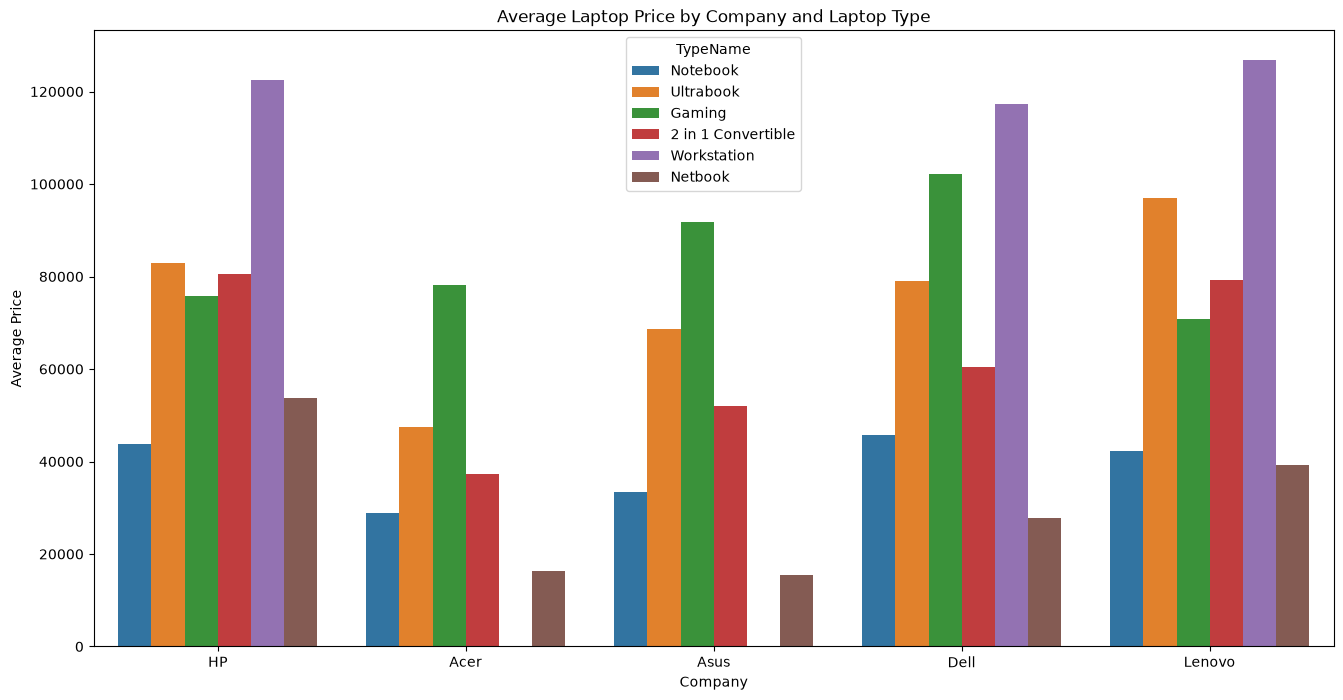

In [51]:
# average price by company and laptop type 'Multivariate analysis'

top_5 = laptop_clean["Company"].value_counts().head(5).index
data_top_5 = laptop_clean[laptop_clean["Company"].isin(top_5)]

plt.figure(figsize=(16, 8))
sns.barplot(data=data_top_5, x="Company", y="Price", hue="TypeName", errorbar=None)
plt.title("Average Laptop Price by Company and Laptop Type")
plt.xlabel("Company")
plt.ylabel("Average Price")
plt.show()

# الرسمة توضح لنا متوسط سعر اللابتوبات حسب الشركة ونوع الجهاز لأكثر خمس شركات وتم اختيار 5 شركات حتى تكون الرسمة واضحة وتركيز على أهم الشركات في البيانات.

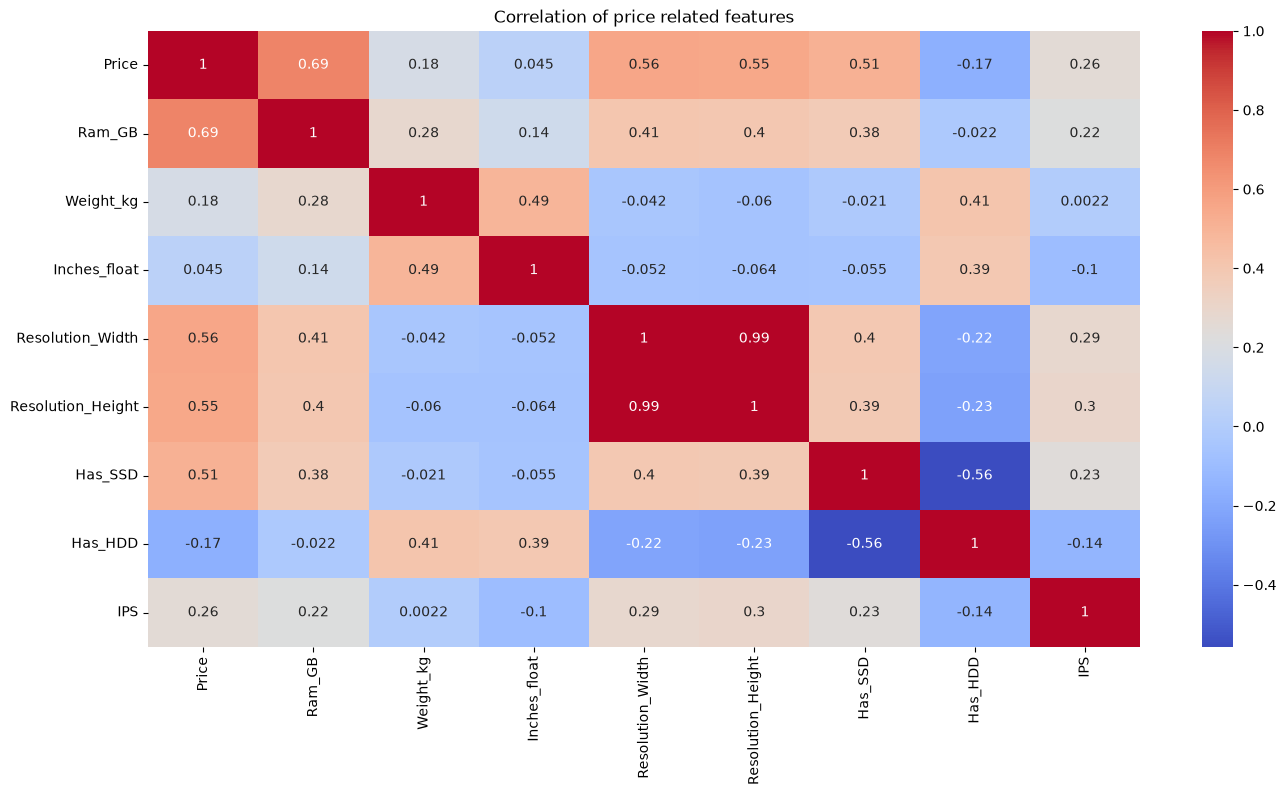

In [52]:
# correlation heatmap 'Multivariate analysis'

numeric_cols = [
    "Price",
    "Ram_GB",
    "Weight_kg",
    "Inches_float",
    "Resolution_Width",
    "Resolution_Height",
    "Has_SSD",
    "Has_HDD",
    "IPS"
]
    
plt.figure(figsize=(16,8))
sns.heatmap(laptop_clean[numeric_cols].corr(), annot=True, cmap= "coolwarm")
plt.title("Correlation of price related features")
plt.show()

صنفت العلاقات لثلاث أنواع حتى تسهل عملية فهم العلاقات بين أهم الأعمدة لدي وكان التركيز أكثر شي على عامود السعر كونه في الجزء المستهدف في التنبؤ.

الرسومات وضحت لنا العلاقات بشكل أفضل خاصة عامود السعر 

# preprocessing

In [53]:
# make a copy for the model

laptop_model = laptop_clean.copy()

In [54]:
# check the text columns (before)
laptop_model.select_dtypes(include="object").columns

C:\Users\SALMAN\AppData\Local\Temp\ipykernel_19716\320750479.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  laptop_model.select_dtypes(include="object").columns


Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'GPU_Brand', 'CPU_Brand',
       'OS_Name'],
      dtype='str')

In [55]:
# removing text columns 
laptop_model = laptop_model.drop(columns=[
    "Ram",
    "Weight",
    "Inches",
    "Cpu",
    "Gpu",
    "Memory",
    "OpSys",
    "ScreenResolution"
])

# هنا حذفت الأعمدة اللى مااحتاجها لانني في مرحلة اسكتشاف البيانات أنشاءت عدة أعمدة جديدة 

In [56]:
# check the text columns 
laptop_model.select_dtypes(include="object").columns

C:\Users\SALMAN\AppData\Local\Temp\ipykernel_19716\4123010219.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  laptop_model.select_dtypes(include="object").columns


Index(['Company', 'TypeName', 'GPU_Brand', 'CPU_Brand', 'OS_Name'], dtype='str')

In [57]:
# encoding 

laptop_model = pd.get_dummies(
    laptop_model,
    columns=["Company", "TypeName", "GPU_Brand", "CPU_Brand", "OS_Name"],
    drop_first=True,
    dtype=int
)



 استخدمت one-hot encoding لتحويل الأعمدة النصية او الفئوية إلى أعمدة رقمية تسهل علينا عملية بناء النموذج

وتم استخدام drop first حتى نتجنب إنشاء معلومات متكررة بين الأعمدة أو لتقليل الارتباط بينهم.

In [58]:
# check after encoding
print("Shape after encoding: ", laptop_model.shape)

Shape after encoding:  (1270, 45)


In [59]:
# scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# separate features and target
X = laptop_model.drop("Price", axis=1)
y = laptop_model["Price"]

# قسمنا الأعمدة إلى قسمين X وهي الاعمدة اللى بتساعدنا على التنبؤ ، y بيكون فيه عامود السعر اللى نبغى نتنبأ


In [60]:
# split data into training and testing 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
# use scale after split to avoid data leakage

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scaler بيسوي fit على بيانات التدريب يتعلم وثم يروح لبيانات الاختبار وبطبق اللى تعلمه 

# PCA - Dimensionality Reduction

In [62]:
from sklearn.decomposition import PCA 


In [63]:
# apply PCA to keep 95% of the variance 

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled) # fit only on the training data
X_test_pca = pca.transform(X_test_scaled) # transform to avoid data leakage

print("Number of features without PCA: ", X_train_scaled.shape[1])
print("Number of features with PCA: ", X_train_pca.shape[1])
print("Cumulative Explained Variance: ", round(pca.explained_variance_ratio_.sum(), 3)) # نسبة المعلومات التي انحفظت في PCA

# هنا سوينا مقارنة قبل وبعد استخدام PCAواللى اظهر لنا نزول من قيم features من 44 إلى 32


Number of features without PCA:  44
Number of features with PCA:  32
Cumulative Explained Variance:  0.958


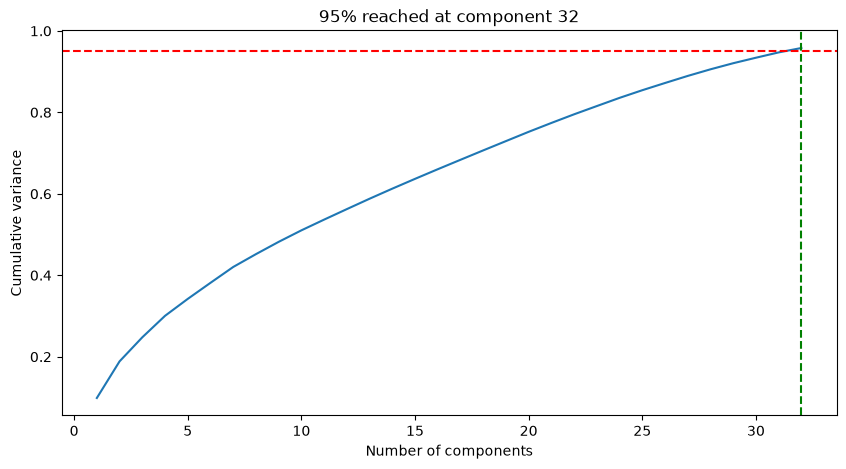

95% reached at component :32
Total components: 32


In [64]:
# 
cumulative = np.cumsum(pca.explained_variance_ratio_)
n_95 = np.argmax(cumulative >= 0.95) + 1

plt.figure(figsize=(10,5))
plt.plot(range(1, len(cumulative) + 1), cumulative)
plt.axhline( 0.95, color="red", linestyle="--")
plt.axvline( n_95, color="green", linestyle="--")
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance")
plt.title("95% reached at component " + str(n_95))
plt.show()

print("95% reached at component :" + str(n_95))
print("Total components:", len(cumulative))

بناء على الرسمة توضح لنا أن (PCA) قلل عدد الخصائص من 44 إلى 32 مع المحافظة على 95% من معلومات البيانات .

# Modeling

In [65]:
# import models

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [66]:
# model 1 is linear regression 

linear_model = LinearRegression()

# train using PCA data
linear_model.fit(X_train_pca, y_train)
# make predictions
y_pred_linear = linear_model.predict(X_test_pca)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear) 
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred_linear)

print("MAE : ", round(linear_mae, 3))
print("MSE : ", round(linear_mse, 3)) 
print("RMSE: ", round(linear_rmse, 3))
print("R2  : ", round(linear_r2, 3))

MAE :  13066.969
MSE :  359233541.256
RMSE:  18953.457
R2  :  0.677


In [67]:
# model 2 is decision tree regressor
tree_model = DecisionTreeRegressor(random_state=42)

#train using PCA data
tree_model.fit(X_train_pca, y_train)
# make predictions
y_pred_tree = tree_model.predict(X_test_pca)

tree_mae = mean_absolute_error(y_test, y_pred_tree)
tree_mse = mean_squared_error(y_test, y_pred_tree) 
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, y_pred_tree)

print("MAE : ", round(tree_mae, 3))
print("MSE : ", round(tree_mse, 3)) 
print("RMSE: ", round(tree_rmse, 3))
print("R2  : ", round(tree_r2, 3))



MAE :  14008.478
MSE :  511566310.25
RMSE:  22617.832
R2  :  0.54


In [68]:
# model 3 is random forest regressor
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)

#train using PCA data
forest_model.fit(X_train_pca, y_train)
# make predictions
y_pred_forest = forest_model.predict(X_test_pca)

forest_mae = mean_absolute_error(y_test, y_pred_forest)
forest_mse = mean_squared_error(y_test, y_pred_forest) 
forest_rmse = np.sqrt(forest_mse)
forest_r2 = r2_score(y_test, y_pred_forest)

print("MAE : ", round(forest_mae, 3))
print("MSE : ", round(forest_mse, 3)) 
print("RMSE: ", round(forest_rmse, 3))
print("R2  : ", round(forest_r2, 3))


MAE :  10431.568
MSE :  216136572.847
RMSE:  14701.584
R2  :  0.806


بعد ما خلصنا الثلاث نماذج من بناء وتدريب واختبار كانت النسب كالتالي :
Linear Regression ≈ 0.677
Decision Tree Regressor ≈ 0.54
Random Forest Regressor ≈ 0.806

بناء عليه أفضل مودل من ناحية الأداة هو : Random Forest Regressor لأنه حصل على أعلى R2 scores و اقل أخطاء في التنبؤ. 

# Evaluation

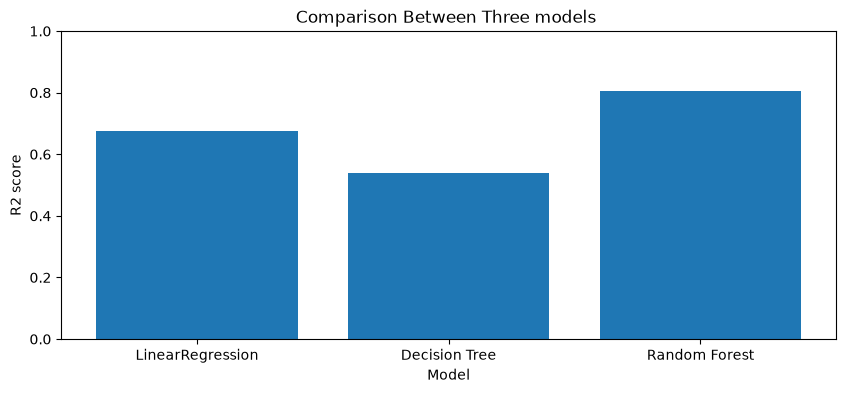

In [69]:
# compare R2 scores for the three models 

models = ["LinearRegression", "Decision Tree", "Random Forest"]
r2_scores = [linear_r2, tree_r2, forest_r2]

plt.figure(figsize=(10,4))
plt.bar(models, r2_scores)

plt.xlabel("Model")
plt.ylabel("R2 score")
plt.title("Comparison Between Three models ")
plt.ylim(0,1)
plt.show()


# Random Forest achieved the highest R2 score.

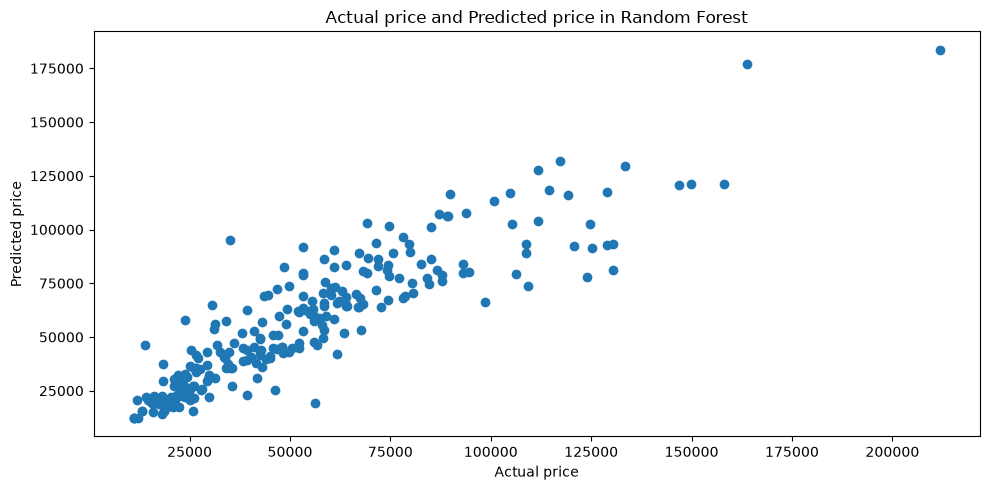

In [70]:
# Compare between the actual price and predicted price (Random forest)

plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_forest)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual price and Predicted price in Random Forest")
plt.tight_layout()
plt.show()

في الرسم اعلاها قارنت بين السعر الحقيقي والسعر المتوقع في نموذج الإنحدار العشوائي 

يوضح ذلك بأن هناك نقاط قريبة وفي اتجاه واحد وهذا يدل أن النموذج يتوقع الأسعار بشكل قريب من الأسعار الحقيقية.

In [71]:
# save the best model

import joblib
import os

# create folder to save models
os.makedirs("saved_models", exist_ok=True)

# collect model scores
model_scores = {
    "Linear Regression": linear_r2,
    "Decision Tree Regressor": tree_r2,
    "Random Forest Regressor": forest_r2
}

# collect trained models
trained_models = {
    "Linear Regression": linear_model,
    "Decision Tree Regressor": tree_model,
    "Random Forest Regressor": forest_model
}

# choose best model based on highest R2 score
best_model_name = max(model_scores, key=model_scores.get)
best_model = trained_models[best_model_name]

# save best model with scaler and PCA
best_model_package = {
    "best_model_name": best_model_name,
    "model": best_model,
    "scaler": scaler,
    "pca": pca,
    "feature_columns": X.columns
}

joblib.dump(best_model_package, "saved_models/best_laptop_price_model.pkl")

print("Best model saved successfully!")
print("Best Model:", best_model_name)

Best model saved successfully!
Best Model: Random Forest Regressor


# Conclusion

في هذا المشروع تم العمل على مراحل تحليل البيانات بداية من تحميل البيانات وتنظيفها إلى بناء نموذج يتنبأ بأسعار اللابتوبات بناء على أهم الأعمدة التي توثر على السعر.


# Useful Insights 

We get useful insights after all all proceesing in these project:

- Lenovo, Dell, and HP have the highest number of laptops, which means these companies are the most common brands in the dataset.
- Windows is the most common operating system in the dataset.
- Laptops with 32GB RAM have higher average prices.
- There is a strong relationship between RAM and price, laptops with higher RAM usually have higher prices.

- The higher the screen resolution the laptop price is increse.

- The most suitable model was Random Forest, it achieved the highest R2 score and lower prediction errors, while the other model performed less than Random Forest.

In [72]:
#عشان يحفظ كلها لستريم ليت


# create folder to save models
os.makedirs("saved_models", exist_ok=True)

# save Linear Regression model
linear_package = {
    "model_name": "Linear Regression",
    "model": linear_model,
    "scaler": scaler,
    "pca": pca,
    "feature_columns": X.columns,
    "metrics": {
        "MAE": linear_mae,
        "MSE": linear_mse,
        "RMSE": linear_rmse,
        "R2": linear_r2
    }
}

joblib.dump(linear_package, "saved_models/linear_regression_model.pkl")


# save Decision Tree Regressor model
tree_package = {
    "model_name": "Decision Tree Regressor",
    "model": tree_model,
    "scaler": scaler,
    "pca": pca,
    "feature_columns": X.columns,
    "metrics": {
        "MAE": tree_mae,
        "MSE": tree_mse,
        "RMSE": tree_rmse,
        "R2": tree_r2
    }
}

joblib.dump(tree_package, "saved_models/decision_tree_model.pkl")


# save Random Forest Regressor model
forest_package = {
    "model_name": "Random Forest Regressor",
    "model": forest_model,
    "scaler": scaler,
    "pca": pca,
    "feature_columns": X.columns,
    "metrics": {
        "MAE": forest_mae,
        "MSE": forest_mse,
        "RMSE": forest_rmse,
        "R2": forest_r2
    }
}

joblib.dump(forest_package, "saved_models/random_forest_model.pkl")

print("All models saved separately successfully!")

All models saved separately successfully!
